# Differentiability in JAXCad

JAXCad is a fully differentiable CAD system: every SDF is a pure JAX function, so gradients flow through geometry just like through any other computation. This makes it straightforward to optimize shape parameters directly with respect to any loss.

In [1]:
import jax
import jax.numpy as jnp

from jaxcad import extract_parameters, functionalize
from jaxcad.geometry import Vector
from jaxcad.render import render_marching_cubes
from jaxcad.sdf import SDF, Sphere, Translate, Union, volume

Because SDFs are plain JAX functions, we can differentiate through them out of the box. As a running example, we define a scene builder that places two unit spheres at positions `p1` and `p2` and returns their union.

In [2]:
def double_sphere(p1: jax.Array, p2: jax.Array) -> SDF:
    radius = 1.0
    sphere1 = Translate(Sphere(radius=radius), offset=p1)
    sphere2 = Translate(Sphere(radius=radius), offset=p2)
    return jax.jit(Union(sphere1, sphere2))

<Axes3D: title={'center': '3D Mesh (Marching Cubes)'}, xlabel='X', ylabel='Y', zlabel='Z'>

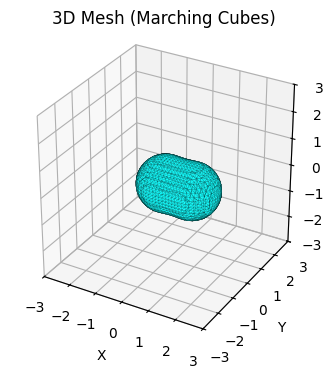

In [3]:
p1 = jnp.array([0.0, 0.0, 0.0])
p2 = jnp.array([1.0, 0.0, 0.0])

render_marching_cubes(double_sphere(p1, p2), figsize=(4, 4))

JAXCad provides a `volume` function that integrates an SDF over a bounding volume. We can use it as a loss and differentiate with respect to the sphere positions using `jax.value_and_grad`.

In [4]:
def loss(p1: jax.Array, p2: jax.Array) -> jax.Array:
    return volume(double_sphere(p1, p2))

In [5]:
grad = jax.value_and_grad(loss, argnums=(0, 1))
value, grads = grad(p1, p2)
print("Loss value:", value)
print("Gradient w.r.t p1:", grads[0])
print("Gradient w.r.t p2:", grads[1])

Loss value: 6.872672
Gradient w.r.t p1: [-1.8908089e+00  2.6822090e-07  5.8858257e-07]
Gradient w.r.t p2: [1.9764318e+00 8.1956387e-07 8.0093946e-07]


Passing positions explicitly works, but scales poorly: complex scenes may have dozens of parameters scattered across the tree. JAXCad lets you tag parameters as *free* directly on the geometry objects, then extract them automatically as a flat dictionary that JAX can differentiate through.

In [10]:
p1 = Vector(jnp.array([0.0, 0.0, 0.0]), free=True, name="p1")
p2 = Vector(jnp.array([1.0, 0.0, 0.0]), free=True, name="p2")
sphere1 = Translate(Sphere(radius=1.0), offset=p1)
sphere2 = Translate(Sphere(radius=1.0), offset=p2)
double_sphere_ = Union(sphere1, sphere2)

`extract_parameters` walks the SDF tree and returns two dictionaries — one for free (differentiable) parameters and one for fixed parameters.

In [11]:
free_params, fixed_params = extract_parameters(double_sphere_)

print("Free parameters:", free_params)

Free parameters: {'translate_1.offset': Vector(value=Array([0., 0., 0.], dtype=float32), free=True, name='p1', bounds=None), 'translate_3.offset': Vector(value=Array([1., 0., 0.], dtype=float32), free=True, name='p2', bounds=None)}


`functionalize` compiles the SDF tree into a curried pure function: given parameter dictionaries it returns a callable `point → distance`. This separates the geometry structure (fixed at compile time) from the parameter values (free to vary).

In [12]:
double_sphere_functional = functionalize(double_sphere_)
double_sphere_functional(free_params, fixed_params)(jnp.array([0.5, 0, 0]))

Array(-0.6, dtype=float32)

We can now differentiate the loss through the parameter dictionary directly.

In [13]:
def loss(params):
    return volume(double_sphere_functional(params, fixed_params))

In [16]:
grad = jax.value_and_grad(loss, argnums=(0))
value, grads = grad(free_params)
print("Loss value:", value)
grads

Loss value: 6.872672


{'translate_1.offset': Vector(value=Array([-1.8908089e+00,  2.6822090e-07,  5.8858257e-07], dtype=float32), free=True, name='p1', bounds=None),
 'translate_3.offset': Vector(value=Array([1.9764318e+00, 8.1956387e-07, 8.0093946e-07], dtype=float32), free=True, name='p2', bounds=None)}

For simple scenes the two approaches are equivalent. The parameter-extraction workflow becomes essential as scenes grow: any node in the tree can declare its parameters free, and the compiler collects them automatically — no changes needed to the loss or optimizer.